## 0. Cấu hình Google Cloud

Sửa lại các path nếu bạn train với `rank`, `iter`, hoặc folder khác.

Theo script train, `recs_path` là output chứa dữ liệu flat recommendation.

In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
PROJECT_ID = "project-79499e5c-69d7-42b8-864"
REGION = "asia-southeast1"
BUCKET = "truong_bigdata_24032026_init"

# Input đã dùng để train ALS, gồm cả split=train/test
INPUT_GCS_PATH = f"gs://{BUCKET}/gold/gold_als_train_split/"

# Output recommendation từ script train ALS bạn gửi.
# Script lưu flat_recs với cột: user_idx, app_idx, als_score
RECS_GCS_PATH = f"gs://{BUCKET}/gold/als_recommendations_rank16_iter5"

# Optional: model path nếu sau này muốn load model để transform test hoặc inspect factors
MODEL_GCS_PATH = f"gs://{BUCKET}//models/als_rank16_iter5"

# Local folder trong Colab
LOCAL_ROOT = "/content/steam_als_eval"
LOCAL_INPUT_PATH = f"{LOCAL_ROOT}/gold_als_train_split"
LOCAL_RECS_PATH = f"{LOCAL_ROOT}/als_recommendations_rank16_iter5"
LOCAL_OUTPUT_DIR = f"{LOCAL_ROOT}/outputs"

# Nếu dữ liệu quá lớn với Colab, giảm sample fraction để kiểm tra nhanh.
# Full evaluation: 1.0
# Test nhanh: 0.02 hoặc 0.05
EVAL_USER_SAMPLE_FRACTION = 1.0
RANDOM_SEED = 42

# Các mức K cần đánh giá
K_LIST = [5, 10, 20, 50]

In [3]:
!gcloud config set project {PROJECT_ID}

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].


## 1. Cài thư viện

In [4]:
!pip install pyspark google-cloud-bigquery db-dtypes gcsfs pyarrow pandas matplotlib -q

## 2. Kiểm tra dữ liệu trên GCS

In [5]:
print("===== INPUT TRAIN/TEST PATH =====")
!gsutil ls -lh {INPUT_GCS_PATH} | head -50

print("\n===== RECOMMENDATION PATH =====")
!gsutil ls -lh {RECS_GCS_PATH} | head -50

print("\nNumber of recommendation part files:")
!gsutil ls {RECS_GCS_PATH}/part-* | wc -l

===== INPUT TRAIN/TEST PATH =====
 12.41 MiB  2026-05-23T17:27:00Z  gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000000.parquet
  12.4 MiB  2026-05-23T17:27:00Z  gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000001.parquet
 12.39 MiB  2026-05-23T17:27:00Z  gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000002.parquet
 12.38 MiB  2026-05-23T17:27:00Z  gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000003.parquet
 12.38 MiB  2026-05-23T17:27:00Z  gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000004.parquet
  12.4 MiB  2026-05-23T17:27:00Z  gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000005.parquet
 12.42 MiB  2026-05-23T17:27:00Z  gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000006.parquet
 12.42 MiB  2026-05-23T17:27:00Z  gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000007.parquet
  12.4 MiB  2026-05-23T17:27:00Z  gs://truong_

## 3. Copy dữ liệu từ GCS về Colab local

PySpark trong Colab thường không đọc trực tiếp `gs://` ổn định nếu thiếu GCS connector. Cách an toàn là copy Parquet về local rồi đọc bằng Spark.

Nếu dữ liệu quá lớn và Colab không đủ disk, bạn nên chạy notebook này trên Dataproc / Vertex AI Workbench hoặc chỉ copy một phần dữ liệu để kiểm thử nhanh.

In [6]:
!rm -rf {LOCAL_ROOT}
!mkdir -p {LOCAL_ROOT}
!mkdir -p {LOCAL_OUTPUT_DIR}

print("Copy train/test split...")
!gsutil -m cp -r {INPUT_GCS_PATH} {LOCAL_ROOT}/

print("Copy recommendations...")
!gsutil -m cp -r {RECS_GCS_PATH} {LOCAL_ROOT}/

print("\nLocal disk usage:")
!du -sh {LOCAL_ROOT}/*

Copy train/test split...
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000000.parquet...
Copying gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000002.parquet...
Copying gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000004.parquet...
Copying gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000003.parquet...
Copying gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000001.parquet...
Copying gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000006.parquet...
Copying gs://truong_bigdata_24032026_init/gold/gold_als_train_split/000000000008.parquet...
Copying gs://truong_bigdata_24032026_init/gold/gold_als_train_split/0000

## 4. Tạo SparkSession

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

spark = (
    SparkSession.builder
    .appName("steam-als-post-training-evaluation-flat-recs")
    .config("spark.sql.shuffle.partitions", "128")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

spark

## 5. Đọc dữ liệu train/test và recommendation

Notebook này ưu tiên schema recommendation flat do script train đã lưu:

```text
user_idx, app_idx, als_score
```

Nếu bạn vô tình đọc output nested `recommendations`, cell bên dưới vẫn tự flatten được.

In [8]:
raw_df = spark.read.parquet(LOCAL_INPUT_PATH)
raw_recs_df = spark.read.parquet(LOCAL_RECS_PATH)

print("===== raw_df schema =====")
raw_df.printSchema()

print("===== raw_recs_df schema =====")
raw_recs_df.printSchema()

print("===== raw_df sample =====")
raw_df.show(5, truncate=False)

print("===== raw_recs_df sample =====")
raw_recs_df.show(5, truncate=False)

===== raw_df schema =====
root
 |-- user_idx: long (nullable = true)
 |-- app_idx: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- app_id: long (nullable = true)
 |-- rating: double (nullable = true)
 |-- review_count: long (nullable = true)
 |-- positive_review_count: long (nullable = true)
 |-- negative_review_count: long (nullable = true)
 |-- unknown_vote_count: long (nullable = true)
 |-- user_num_items: long (nullable = true)
 |-- game_num_users: long (nullable = true)
 |-- rn_random: long (nullable = true)
 |-- n_items: long (nullable = true)
 |-- test_count: long (nullable = true)
 |-- split: string (nullable = true)

===== raw_recs_df schema =====
root
 |-- user_idx: integer (nullable = true)
 |-- app_idx: integer (nullable = true)
 |-- als_score: float (nullable = true)

===== raw_df sample =====
+--------+-------+-----------------+-------+------------------+------------+---------------------+---------------------+------------------+--------------+-----------

In [9]:
# Chuẩn hóa train/test theo đúng script train ALS
base_interactions = (
    raw_df
    .select(
        F.col("user_idx").cast("int").alias("user_idx"),
        F.col("app_idx").cast("int").alias("app_idx"),
        F.col("rating").cast("float").alias("rating"),
        F.col("split").alias("split")
    )
    .filter(
        F.col("user_idx").isNotNull()
        & F.col("app_idx").isNotNull()
        & F.col("rating").isNotNull()
        & (F.col("rating") > 0)
        & F.col("split").isin("train", "test")
    )
)

train_df = base_interactions.filter(F.col("split") == "train").drop("split").cache()
test_df = base_interactions.filter(F.col("split") == "test").drop("split").cache()

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

train_df.show(5)
test_df.show(5)

Train rows: 27509067
Test rows: 5753423
+--------+-------+---------+
|user_idx|app_idx|   rating|
+--------+-------+---------+
|  833616|    767| 3.360073|
|    7539|   6425|      1.0|
|  744898|  37267| 2.042212|
|  162345|  33356| 1.290122|
|  773639|  25560|1.2525926|
+--------+-------+---------+
only showing top 5 rows
+--------+-------+---------+
|user_idx|app_idx|   rating|
+--------+-------+---------+
| 3020642|  37267|1.8374457|
|   48505|  23900|3.1106803|
| 2818115|  36119| 2.895926|
| 2948242|  44448|2.4715824|
| 2614335|  17535|3.2642505|
+--------+-------+---------+
only showing top 5 rows


In [10]:
# Chuẩn hóa recommendation.
# Case 1: flat output từ script bạn gửi: user_idx, app_idx, als_score
# Case 2: nested output Spark ALS: user_idx, recommendations array<struct<app_idx, rating>>

rec_cols = set(raw_recs_df.columns)

if {"user_idx", "app_idx", "als_score"}.issubset(rec_cols):
    print("Detected FLAT recommendation schema: user_idx, app_idx, als_score")
    recs_exploded = (
        raw_recs_df
        .select(
            F.col("user_idx").cast("int").alias("user_idx"),
            F.col("app_idx").cast("int").alias("app_idx"),
            F.col("als_score").cast("float").alias("pred_score")
        )
    )
elif {"user_idx", "app_idx", "rating"}.issubset(rec_cols):
    print("Detected FLAT recommendation schema: user_idx, app_idx, rating")
    recs_exploded = (
        raw_recs_df
        .select(
            F.col("user_idx").cast("int").alias("user_idx"),
            F.col("app_idx").cast("int").alias("app_idx"),
            F.col("rating").cast("float").alias("pred_score")
        )
    )
elif {"user_idx", "recommendations"}.issubset(rec_cols):
    print("Detected NESTED recommendation schema: user_idx, recommendations")
    recs_exploded = (
        raw_recs_df
        .select("user_idx", F.posexplode("recommendations").alias("pos", "rec"))
        .select(
            F.col("user_idx").cast("int").alias("user_idx"),
            F.col("rec.app_idx").cast("int").alias("app_idx"),
            F.col("rec.rating").cast("float").alias("pred_score")
        )
    )
else:
    raise ValueError(f"Unsupported recommendation schema: {raw_recs_df.columns}")

recs_exploded = (
    recs_exploded
    .filter(
        F.col("user_idx").isNotNull()
        & F.col("app_idx").isNotNull()
        & F.col("pred_score").isNotNull()
    )
    .cache()
)

print("Recommendation rows:", recs_exploded.count())
recs_exploded.printSchema()
recs_exploded.show(10)

Detected FLAT recommendation schema: user_idx, app_idx, als_score
Recommendation rows: 154209900
root
 |-- user_idx: integer (nullable = true)
 |-- app_idx: integer (nullable = true)
 |-- pred_score: float (nullable = true)

+--------+-------+----------+
|user_idx|app_idx|pred_score|
+--------+-------+----------+
|     261|   2415| 1.0672394|
|     261|   3785|  1.040328|
|     261|  12338| 0.9825832|
|     261|   2476|0.84459066|
|     261|   2362| 0.8421055|
|     261|   8911| 0.8302743|
|     261|   1927| 0.8270008|
|     261|   4255| 0.8099345|
|     261|    995| 0.8095543|
|     261|   2182|0.78451395|
+--------+-------+----------+
only showing top 10 rows


## 6. Nếu Colab yếu, lấy mẫu user để đánh giá nhanh

Mặc định `EVAL_USER_SAMPLE_FRACTION = 1.0`, tức là đánh giá full. Nếu chạy chậm, đặt `0.02` hoặc `0.05` ở phần cấu hình.

In [11]:
if EVAL_USER_SAMPLE_FRACTION < 1.0:
    sampled_users = (
        test_df.select("user_idx").distinct()
        .sample(False, EVAL_USER_SAMPLE_FRACTION, seed=RANDOM_SEED)
        .cache()
    )
    print("Sampled eval users:", sampled_users.count())

    train_eval_df = train_df.join(sampled_users, on="user_idx", how="inner").cache()
    test_eval_df = test_df.join(sampled_users, on="user_idx", how="inner").cache()
    recs_eval_df = recs_exploded.join(sampled_users, on="user_idx", how="inner").cache()
else:
    train_eval_df = train_df
    test_eval_df = test_df
    recs_eval_df = recs_exploded

print("Eval train rows:", train_eval_df.count())
print("Eval test rows:", test_eval_df.count())
print("Eval recommendation rows:", recs_eval_df.count())

Eval train rows: 27509067
Eval test rows: 5753423
Eval recommendation rows: 154209900


## 7. Kiểm tra tổng quan dữ liệu

In [12]:
def basic_stats(df, name):
    print(f"===== {name} =====")
    df.select(
        F.count("*").alias("rows"),
        F.countDistinct("user_idx").alias("num_users"),
        F.countDistinct("app_idx").alias("num_games")
    ).show(truncate=False)

basic_stats(train_eval_df, "TRAIN")
basic_stats(test_eval_df, "TEST")
basic_stats(recs_eval_df, "RECOMMENDATIONS")

print("===== Rating stats =====")
train_eval_df.select("rating").summary().show()
test_eval_df.select("rating").summary().show()

print("===== ALS score stats =====")
recs_eval_df.select("pred_score").summary().show()

===== TRAIN =====
+--------+---------+---------+
|rows    |num_users|num_games|
+--------+---------+---------+
|27509067|3084198  |45451    |
+--------+---------+---------+

===== TEST =====
+-------+---------+---------+
|rows   |num_users|num_games|
+-------+---------+---------+
|5753423|3084198  |43369    |
+-------+---------+---------+

===== RECOMMENDATIONS =====
+---------+---------+---------+
|rows     |num_users|num_games|
+---------+---------+---------+
|154209900|3084198  |1158     |
+---------+---------+---------+

===== Rating stats =====
+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|          27509067|
|   mean| 3.030830311025122|
| stddev|0.5790209134082401|
|    min|               1.0|
|    25%|         2.7060926|
|    50%|          3.048021|
|    75%|         3.4036896|
|    max|          4.727796|
+-------+------------------+

+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count

In [13]:
# Mỗi user có bao nhiêu item được recommend?
recs_len_df = (
    recs_eval_df
    .groupBy("user_idx")
    .agg(F.count("*").alias("num_recs"))
    .cache()
)

recs_len_df.select("num_recs").summary().show()

recs_len_df.groupBy("num_recs") \
    .count() \
    .orderBy("num_recs") \
    .show(100, truncate=False)

+-------+--------+
|summary|num_recs|
+-------+--------+
|  count| 3084198|
|   mean|    50.0|
| stddev|     0.0|
|    min|      50|
|    25%|      50|
|    50%|      50|
|    75%|      50|
|    max|      50|
+-------+--------+

+--------+-------+
|num_recs|count  |
+--------+-------+
|50      |3084198|
+--------+-------+



## 8. Kiểm tra user trong test có recommendation không

In [14]:
test_users = test_eval_df.select("user_idx").distinct()
rec_users = recs_eval_df.select("user_idx").distinct()

missing_test_users = test_users.join(rec_users, on="user_idx", how="left_anti")

num_test_users = test_users.count()
num_rec_users = rec_users.count()
num_missing = missing_test_users.count()

print("Test users:", num_test_users)
print("Users with recommendations:", num_rec_users)
print("Test users without recommendations:", num_missing)
print("Missing ratio:", num_missing / num_test_users if num_test_users else None)

missing_test_users.show(20)

Test users: 3084198
Users with recommendations: 3084198
Test users without recommendations: 0
Missing ratio: 0.0
+--------+
|user_idx|
+--------+
+--------+



## 9. Rank recommendation theo từng user

Do script train lưu flat recommendation không có cột rank, ta tự tạo lại `rank` bằng cách sort `pred_score` giảm dần theo từng user.

In [15]:
w_rank = Window.partitionBy("user_idx").orderBy(F.desc("pred_score"), F.asc("app_idx"))

ranked_recs = (
    recs_eval_df
    .withColumn("rank", F.row_number().over(w_rank))
    .cache()
)

ranked_recs.show(20)

+--------+-------+----------+----+
|user_idx|app_idx|pred_score|rank|
+--------+-------+----------+----+
|     273|  26570| 1.0913078|   1|
|     273|  25374| 1.0734835|   2|
|     273|  13579| 1.0629983|   3|
|     273|   8621| 1.0340235|   4|
|     273|   9642| 0.9975411|   5|
|     273|   8215|0.98305386|   6|
|     273|   4399| 0.9589196|   7|
|     273|  15049|0.95013213|   8|
|     273|  24486| 0.8826694|   9|
|     273|   6564|0.86851376|  10|
|     273|  31253|0.84908086|  11|
|     273|  20765| 0.8444143|  12|
|     273|  28181|0.82870233|  13|
|     273|   3483| 0.8270584|  14|
|     273|  17721| 0.7825792|  15|
|     273|  29648| 0.7685882|  16|
|     273|   2943|0.76600546|  17|
|     273|  14759|0.76557386|  18|
|     273|  32990| 0.7565327|  19|
|     273|   6322|0.75254804|  20|
+--------+-------+----------+----+
only showing top 20 rows


## 10. Kiểm tra recommendation có trùng item trong train không

Về lý tưởng, recommendation không nên đề xuất lại game user đã tương tác trong train. Tuy nhiên `recommendForAllUsers` có thể vẫn tạo candidate từ toàn bộ item factors, nên cần kiểm tra.

In [16]:
seen_train_items = train_eval_df.select("user_idx", "app_idx").distinct()

repeated_seen_items = (
    ranked_recs
    .join(seen_train_items, on=["user_idx", "app_idx"], how="inner")
    .cache()
)

num_repeated = repeated_seen_items.count()
num_total_recs = ranked_recs.count()

print("Repeated train items in recommendations:", num_repeated)
print("Total recommendations:", num_total_recs)
print("Repeated ratio:", num_repeated / num_total_recs if num_total_recs else None)

repeated_seen_items.orderBy("user_idx", "rank").show(20)

Repeated train items in recommendations: 13353001
Total recommendations: 154209900
Repeated ratio: 0.08658977795848385
+--------+-------+----------+----+
|user_idx|app_idx|pred_score|rank|
+--------+-------+----------+----+
|       0|   3316| 0.8811782|   1|
|       0|  13749| 0.8577419|   3|
|       0|   6235|0.76915735|   5|
|       0|  15657| 0.7633541|   7|
|       0|  15821| 0.6893477|  11|
|       0|  13362| 0.6790406|  13|
|       1|    243|0.57638806|   5|
|       1|   1327|0.49617198|  13|
|       1|   3773|0.41167006|  27|
|       2|  29648|0.49991116|  13|
|       2|   5221|0.44749862|  20|
|       3|   7527|0.76487404|   4|
|       3|  18587|0.52509946|  29|
|       4|  28834|0.79817635|   2|
|       4|   2648| 0.7212578|   5|
|       4|   9160|0.62113214|  17|
|       4|  21673|   0.51556|  40|
|       5|  15890| 0.4069843|   1|
|       6|   4721|0.92958516|   3|
|       6|  17350| 0.8946455|   5|
+--------+-------+----------+----+
only showing top 20 rows


## 11. Vẽ phân phối ALS score

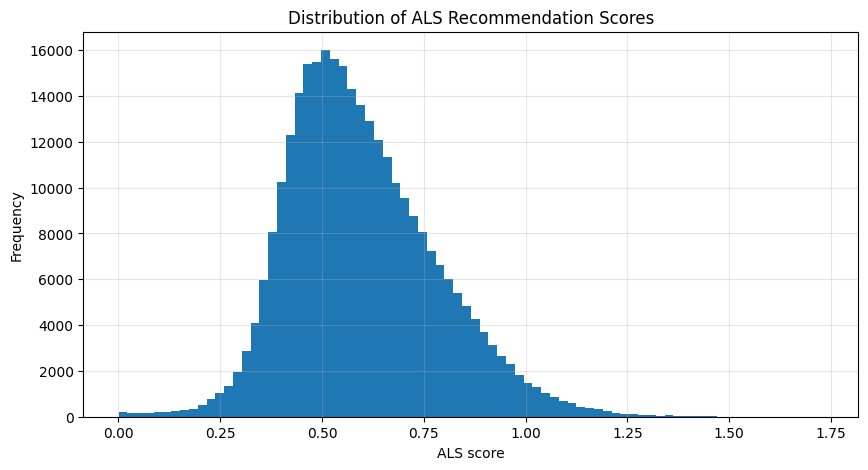

In [17]:
score_sample = (
    ranked_recs
    .select("pred_score")
    .sample(False, 0.01, seed=RANDOM_SEED)
    .limit(300000)
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.hist(score_sample["pred_score"], bins=80)
plt.title("Distribution of ALS Recommendation Scores")
plt.xlabel("ALS score")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

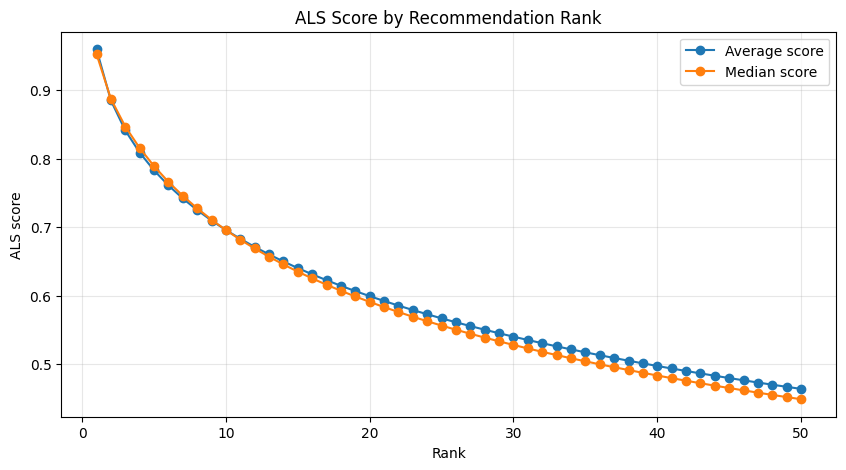

,rank,avg_score,median_score,count
0,1,0.959738,0.952910,3084198
1,2,0.885049,0.887309,3084198
2,3,0.841222,0.846935,3084198
3,4,0.809005,0.815626,3084198
4,5,0.783010,0.789179,3084198


In [18]:
# Score trung bình theo rank: top rank nên có score cao hơn các rank sau
rank_score_pd = (
    ranked_recs
    .groupBy("rank")
    .agg(
        F.avg("pred_score").alias("avg_score"),
        F.expr("percentile_approx(pred_score, 0.5)").alias("median_score"),
        F.count("*").alias("count")
    )
    .orderBy("rank")
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.plot(rank_score_pd["rank"], rank_score_pd["avg_score"], marker="o", label="Average score")
plt.plot(rank_score_pd["rank"], rank_score_pd["median_score"], marker="o", label="Median score")
plt.title("ALS Score by Recommendation Rank")
plt.xlabel("Rank")
plt.ylabel("ALS score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rank_score_pd.head()

## 12. Kiểm tra độ chênh top 1 và top K

Nếu top 1 và top 50 quá sát nhau, model có thể phân biệt ranking chưa mạnh.

In [19]:
max_k = max(K_LIST)

top_gap = (
    ranked_recs
    .groupBy("user_idx")
    .agg(
        F.max(F.when(F.col("rank") == 1, F.col("pred_score"))).alias("top1_score"),
        F.max(F.when(F.col("rank") == max_k, F.col("pred_score"))).alias(f"top{max_k}_score")
    )
    .withColumn(f"gap_top1_top{max_k}", F.col("top1_score") - F.col(f"top{max_k}_score"))
    .cache()
)

top_gap.summary().show()

+-------+------------------+-------------------+-------------------+------------------+
|summary|          user_idx|         top1_score|        top50_score|    gap_top1_top50|
+-------+------------------+-------------------+-------------------+------------------+
|  count|           3084198|            3084198|            3084198|           3084198|
|   mean|1542597.8752268823| 0.9597379483794843| 0.4641124129650579|0.4956255354152917|
| stddev| 890607.8797930771|0.19149973093009467|0.11926254293882564|0.1197538369201652|
|    min|                 0|        4.294776E-4|       2.1397827E-4|      1.7928821E-4|
|    25%|            771213|          0.8516959|         0.38759395|        0.42189977|
|    50%|           1542365|         0.95291036|         0.44905165|        0.49312198|
|    75%|           2313610|          1.0743039|         0.52929676|         0.5670549|
|    max|           3085184|          2.0872915|           1.221666|         1.2390608|
+-------+------------------+----

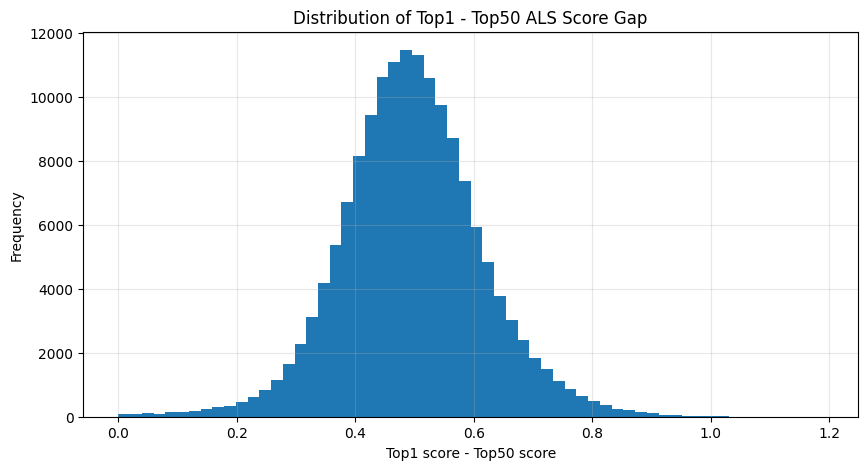

In [20]:
gap_col = f"gap_top1_top{max_k}"

gap_sample = (
    top_gap
    .select(gap_col)
    .sample(False, 0.05, seed=RANDOM_SEED)
    .limit(300000)
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.hist(gap_sample[gap_col].dropna(), bins=60)
plt.title(f"Distribution of Top1 - Top{max_k} ALS Score Gap")
plt.xlabel(f"Top1 score - Top{max_k} score")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

## 13. Chuẩn bị test items cho ranking metrics

Với implicit ALS, đánh giá quan trọng nhất là item trong test có xuất hiện trong top-K recommendation hay không.

In [21]:
test_items = (
    test_eval_df
    .select("user_idx", "app_idx")
    .distinct()
    .cache()
)

print("Test items:", test_items.count())
test_items.show(10)

Test items: 5753423
+--------+-------+
|user_idx|app_idx|
+--------+-------+
| 2342733|  22064|
|  359635|  16233|
|  747208|  19445|
|  145431|  13955|
| 2503423|  16075|
| 2419555|  39864|
|   51816|  38241|
|  114974|  30571|
| 1894624|   9558|
|  123628|  21729|
+--------+-------+
only showing top 10 rows


## 14. Precision@K, Recall@K, HitRate@K

In [22]:
def compute_precision_recall_hit_rate(ranked_recs, test_items, k):
    recs_k = (
        ranked_recs
        .filter(F.col("rank") <= k)
        .select("user_idx", "app_idx", "rank", "pred_score")
    )

    hits = (
        recs_k
        .join(test_items, on=["user_idx", "app_idx"], how="inner")
        .select("user_idx", "app_idx", "rank")
    )

    user_test_count = (
        test_items
        .groupBy("user_idx")
        .agg(F.count("*").alias("num_test_items"))
    )

    user_hit_count = (
        hits
        .groupBy("user_idx")
        .agg(F.count("*").alias("num_hits"))
    )

    metrics_user = (
        user_test_count
        .join(user_hit_count, on="user_idx", how="left")
        .fillna({"num_hits": 0})
        .withColumn("precision_at_k", F.col("num_hits") / F.lit(k))
        .withColumn("recall_at_k", F.col("num_hits") / F.col("num_test_items"))
        .withColumn("hit_rate_at_k", F.when(F.col("num_hits") > 0, 1.0).otherwise(0.0))
    )

    metrics_final = (
        metrics_user
        .agg(
            F.count("*").alias("num_eval_users"),
            F.avg("precision_at_k").alias(f"precision_at_{k}"),
            F.avg("recall_at_k").alias(f"recall_at_{k}"),
            F.avg("hit_rate_at_k").alias(f"hit_rate_at_{k}"),
            F.avg("num_hits").alias("avg_hits_per_user"),
            F.avg("num_test_items").alias("avg_test_items_per_user")
        )
    )

    return metrics_final, metrics_user, hits

In [23]:
for k in K_LIST:
    metrics_k, _, _ = compute_precision_recall_hit_rate(ranked_recs, test_items, k)
    print(f"===== Precision / Recall / HitRate @{k} =====")
    metrics_k.show(truncate=False)

===== Precision / Recall / HitRate @5 =====
+--------------+-------------------+--------------------+------------------+-------------------+-----------------------+
|num_eval_users|precision_at_5     |recall_at_5         |hit_rate_at_5     |avg_hits_per_user  |avg_test_items_per_user|
+--------------+-------------------+--------------------+------------------+-------------------+-----------------------+
|3084198       |0.01810422028680604|0.055267424498501645|0.0869373496772905|0.09052110143382494|1.8654518938148588     |
+--------------+-------------------+--------------------+------------------+-------------------+-----------------------+

===== Precision / Recall / HitRate @10 =====
+--------------+-------------------+-------------------+-------------------+-------------------+-----------------------+
|num_eval_users|precision_at_10    |recall_at_10       |hit_rate_at_10     |avg_hits_per_user  |avg_test_items_per_user|
+--------------+-------------------+-------------------+-------

## 15. NDCG@K

NDCG đánh giá item đúng có nằm ở vị trí cao hay không. Nếu hit ở rank 1 thì tốt hơn hit ở rank 50.

In [24]:
def compute_ndcg_at_k(ranked_recs, test_items, k):
    recs_k = (
        ranked_recs
        .filter(F.col("rank") <= k)
        .select("user_idx", "app_idx", "rank")
    )

    hits = (
        recs_k
        .join(test_items, on=["user_idx", "app_idx"], how="inner")
        .withColumn("dcg_gain", F.lit(1.0) / F.log2(F.col("rank") + F.lit(1.0)))
    )

    dcg_user = (
        hits
        .groupBy("user_idx")
        .agg(F.sum("dcg_gain").alias("dcg"))
    )

    test_count = (
        test_items
        .groupBy("user_idx")
        .agg(F.count("*").alias("num_test_items"))
    )

    idcg_user = (
        test_count
        .withColumn("ideal_len", F.least(F.col("num_test_items"), F.lit(k)))
        .withColumn("ideal_rank", F.explode(F.sequence(F.lit(1), F.col("ideal_len"))))
        .withColumn("idcg_gain", F.lit(1.0) / F.log2(F.col("ideal_rank") + F.lit(1.0)))
        .groupBy("user_idx")
        .agg(F.sum("idcg_gain").alias("idcg"))
    )

    ndcg_user = (
        test_count
        .join(dcg_user, on="user_idx", how="left")
        .join(idcg_user, on="user_idx", how="inner")
        .fillna({"dcg": 0.0})
        .withColumn("ndcg_at_k", F.when(F.col("idcg") > 0, F.col("dcg") / F.col("idcg")).otherwise(0.0))
    )

    ndcg_final = (
        ndcg_user
        .agg(
            F.count("*").alias("num_eval_users"),
            F.avg("ndcg_at_k").alias(f"ndcg_at_{k}")
        )
    )

    return ndcg_final, ndcg_user

In [25]:
for k in K_LIST:
    ndcg_k, _ = compute_ndcg_at_k(ranked_recs, test_items, k)
    print(f"===== NDCG@{k} =====")
    ndcg_k.show(truncate=False)

===== NDCG@5 =====
+--------------+-------------------+
|num_eval_users|ndcg_at_5          |
+--------------+-------------------+
|3084198       |0.03949238791368351|
+--------------+-------------------+

===== NDCG@10 =====
+--------------+-------------------+
|num_eval_users|ndcg_at_10         |
+--------------+-------------------+
|3084198       |0.05359723924732736|
+--------------+-------------------+

===== NDCG@20 =====
+--------------+-------------------+
|num_eval_users|ndcg_at_20         |
+--------------+-------------------+
|3084198       |0.07110244570834545|
+--------------+-------------------+

===== NDCG@50 =====
+--------------+-------------------+
|num_eval_users|ndcg_at_50         |
+--------------+-------------------+
|3084198       |0.09743663373258514|
+--------------+-------------------+



## 16. MAP@K

MAP đánh giá trung bình precision tại các vị trí hit.

In [26]:
def compute_map_at_k(ranked_recs, test_items, k):
    recs_k = (
        ranked_recs
        .filter(F.col("rank") <= k)
        .select("user_idx", "app_idx", "rank")
    )

    hits = (
        recs_k
        .join(test_items, on=["user_idx", "app_idx"], how="inner")
    )

    w_hit = Window.partitionBy("user_idx").orderBy("rank")

    hits_precision = (
        hits
        .withColumn("hit_order", F.row_number().over(w_hit))
        .withColumn("precision_at_hit", F.col("hit_order") / F.col("rank"))
    )

    test_count = (
        test_items
        .groupBy("user_idx")
        .agg(F.count("*").alias("num_test_items"))
    )

    ap_user = (
        test_count
        .join(
            hits_precision
            .groupBy("user_idx")
            .agg(F.sum("precision_at_hit").alias("sum_precision_at_hits")),
            on="user_idx",
            how="left"
        )
        .fillna({"sum_precision_at_hits": 0.0})
        .withColumn("normalizer", F.least(F.col("num_test_items"), F.lit(k)))
        .withColumn("ap_at_k", F.when(F.col("normalizer") > 0, F.col("sum_precision_at_hits") / F.col("normalizer")).otherwise(0.0))
    )

    map_final = (
        ap_user
        .agg(
            F.count("*").alias("num_eval_users"),
            F.avg("ap_at_k").alias(f"map_at_{k}")
        )
    )

    return map_final, ap_user

In [27]:
for k in K_LIST:
    map_k, _ = compute_map_at_k(ranked_recs, test_items, k)
    print(f"===== MAP@{k} =====")
    map_k.show(truncate=False)

===== MAP@5 =====
+--------------+--------------------+
|num_eval_users|map_at_5            |
+--------------+--------------------+
|3084198       |0.028663564509579506|
+--------------+--------------------+

===== MAP@10 =====
+--------------+--------------------+
|num_eval_users|map_at_10           |
+--------------+--------------------+
|3084198       |0.033815538256279906|
+--------------+--------------------+

===== MAP@20 =====
+--------------+-------------------+
|num_eval_users|map_at_20          |
+--------------+-------------------+
|3084198       |0.03833979771875139|
+--------------+-------------------+

===== MAP@50 =====
+--------------+-------------------+
|num_eval_users|map_at_50          |
+--------------+-------------------+
|3084198       |0.04255562429854352|
+--------------+-------------------+



## 18. Catalog Coverage

Coverage cho biết mô hình recommend được bao nhiêu game khác nhau so với tổng số game có trong train.

In [29]:
total_train_items = train_eval_df.select("app_idx").distinct().count()
total_recommended_items = ranked_recs.select("app_idx").distinct().count()

catalog_coverage = total_recommended_items / total_train_items if total_train_items else 0.0

coverage_pd = pd.DataFrame([{
    "total_train_items": total_train_items,
    "total_recommended_items": total_recommended_items,
    "catalog_coverage": catalog_coverage
}])

coverage_pd

,total_train_items,total_recommended_items,catalog_coverage
0,45451,1158,0.025478


## 19. Popularity Bias

Kiểm tra mô hình có đề xuất quá nhiều game phổ biến không.

In [31]:
item_popularity = (
    train_eval_df
    .groupBy("app_idx")
    .agg(F.countDistinct("user_idx").alias("train_user_count"))
    .cache()
)

rec_popularity = (
    ranked_recs
    .join(item_popularity, on="app_idx", how="left")
    .fillna({"train_user_count": 0})
    .cache()
)

rec_popularity.select("train_user_count").summary().show()

+-------+------------------+
|summary|  train_user_count|
+-------+------------------+
|  count|         154209900|
|   mean|58196.755700431684|
| stddev| 58893.55571151545|
|    min|              2162|
|    25%|             21401|
|    50%|             36154|
|    75%|             74268|
|    max|            378133|
+-------+------------------+



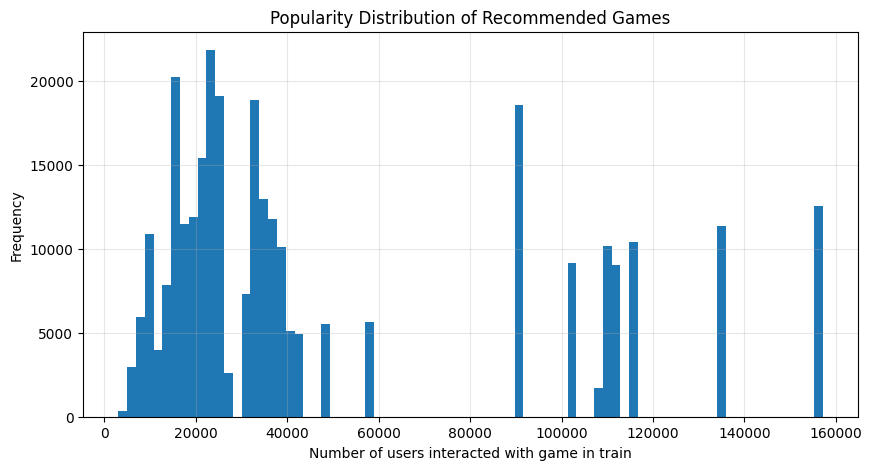

In [32]:
popularity_sample = (
    rec_popularity
    .select("train_user_count")
    .sample(False, 0.01, seed=RANDOM_SEED)
    .limit(300000)
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.hist(popularity_sample["train_user_count"], bins=80)
plt.title("Popularity Distribution of Recommended Games")
plt.xlabel("Number of users interacted with game in train")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

## 20. Novelty

Novelty càng cao nghĩa là recommendation càng ít phổ biến, có tính mới lạ hơn.

In [33]:
num_train_users = train_eval_df.select("user_idx").distinct().count()

item_novelty = (
    item_popularity
    .withColumn(
        "novelty",
        -F.log2((F.col("train_user_count") + F.lit(1.0)) / F.lit(num_train_users + 1.0))
    )
)

rec_novelty = ranked_recs.join(item_novelty, on="app_idx", how="left")

novelty_stats = rec_novelty.agg(
    F.avg("novelty").alias("avg_novelty"),
    F.expr("percentile_approx(novelty, 0.25)").alias("p25_novelty"),
    F.expr("percentile_approx(novelty, 0.50)").alias("p50_novelty"),
    F.expr("percentile_approx(novelty, 0.75)").alias("p75_novelty"),
    F.max("novelty").alias("max_novelty")
)

novelty_stats.show(truncate=False)

+-----------------+-----------------+-----------------+-----------------+------------------+
|avg_novelty      |p25_novelty      |p50_novelty      |p75_novelty      |max_novelty       |
+-----------------+-----------------+-----------------+-----------------+------------------+
|6.286947243263825|5.375991891038482|6.414556867953498|7.171006422575554|10.477646473801544|
+-----------------+-----------------+-----------------+-----------------+------------------+

